# 👥 Phase 4: Behavioral Segmentation
**Algorithm:** K-means Clustering on Deep Features  
---

## 1️⃣ Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


## 2️⃣ Load Deep Features

In [2]:
train_features = np.load('../outputs/reports/deep_features_train.npy')
y_train = np.load('../outputs/reports/y_train.npy')
print(f'✅ Features Shape: {train_features.shape}')
print(f'✅ Labels Shape: {y_train.shape}')

✅ Features Shape: (16675, 32)
✅ Labels Shape: (16675,)


## 3️⃣ Find Optimal K

K=2 → Silhouette: 0.335
K=3 → Silhouette: 0.339
K=4 → Silhouette: 0.324
K=5 → Silhouette: 0.311
K=6 → Silhouette: 0.323
K=7 → Silhouette: 0.305
K=8 → Silhouette: 0.315
K=9 → Silhouette: 0.322
K=10 → Silhouette: 0.307


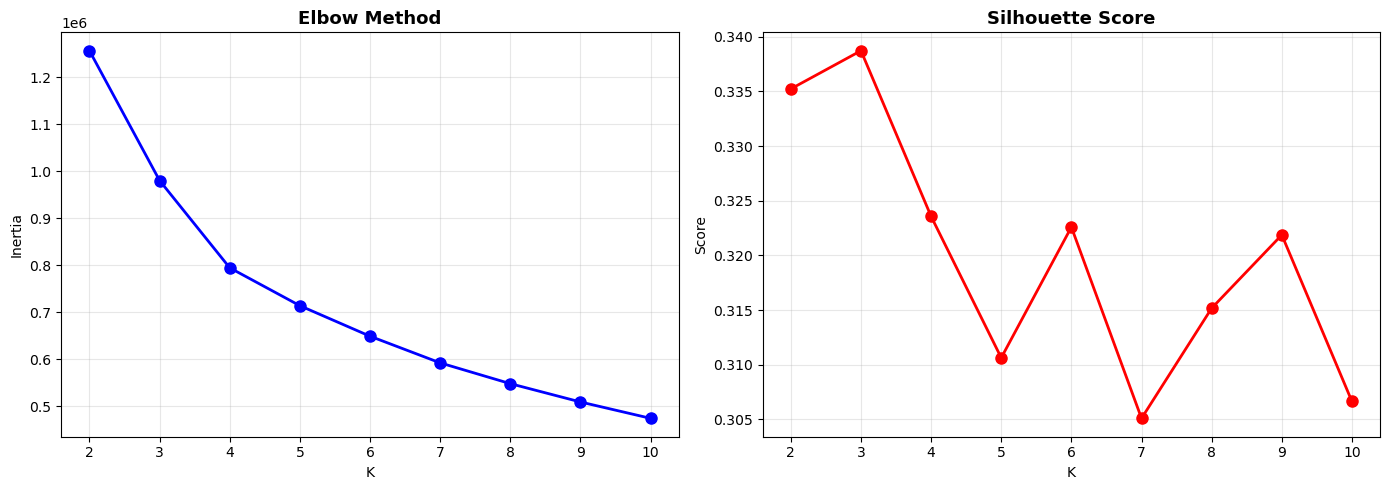

✅ Optimal K = 3


In [3]:
inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(train_features)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(train_features, km.labels_))
    print(f'K={k} → Silhouette: {silhouettes[-1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].grid(True, alpha=0.3)
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/optimal_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()
optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f'✅ Optimal K = {optimal_k}')

## 4️⃣ Apply K-means & Visualize

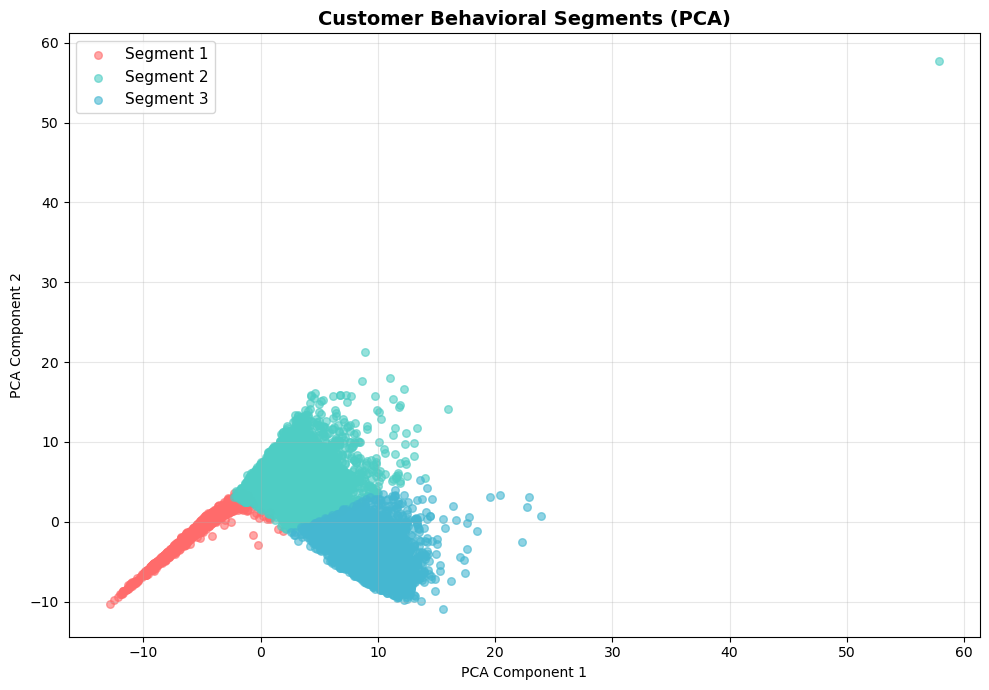

In [4]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(train_features)

pca = PCA(n_components=2)
features_2d = pca.fit_transform(train_features)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
plt.figure(figsize=(10, 7))
for i in range(optimal_k):
    mask = labels == i
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
               c=colors[i], label=f'Segment {i+1}', alpha=0.6, s=30)
plt.title('Customer Behavioral Segments (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1'); plt.ylabel('PCA Component 2')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/customer_segments.png', dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ Analyze Segments

In [5]:
for i in range(optimal_k):
    mask = labels == i
    rate = y_train[mask].mean() * 100
    action = '🟢 VIP - Loyalty Rewards' if rate >= 70 else '🟡 Warm - Personalized Offers' if rate >= 40 else '🔴 Cold - Re-engagement'
    print(f'Segment {i+1}: Size={mask.sum()} | Purchase Rate={rate:.2f}% | Action={action}')
np.save('../outputs/reports/cluster_labels_train.npy', labels)
print('✅ Segmentation Complete!')

Segment 1: Size=8752 | Purchase Rate=94.38% | Action=🟢 VIP - Loyalty Rewards
Segment 2: Size=4160 | Purchase Rate=1.88% | Action=🔴 Cold - Re-engagement
Segment 3: Size=3763 | Purchase Rate=0.00% | Action=🔴 Cold - Re-engagement
✅ Segmentation Complete!
